In [6]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully")

Libraries imported successfully


In [9]:
df = pd.read_csv('/kaggle/input/datasets/syedafatimazahra123/churn-prediction/WA_Fn-UseC_-Telco-Customer-Churn.csv')

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [10]:
print("Missing values")
df.isnull().sum()

Missing values


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [11]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

print("Missing values after cleaning:", df.isnull().sum().sum())

Missing values after cleaning: 0


## Data Encoding
Convert categorical variables into numerical format for machine learning.

In [12]:
categorical_cols = [
'gender','Partner','Dependents','PhoneService',
'MultipleLines','InternetService','OnlineSecurity',
'OnlineBackup','DeviceProtection','TechSupport',
'StreamingTV','StreamingMovies','Contract',
'PaperlessBilling','PaymentMethod'
]

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("Original columns:", df.shape[1])
print("After encoding:", df_encoded.shape[1])

Original columns: 21
After encoding: 32


In [13]:
df_encoded['Churn'] = df_encoded['Churn'].map({'Yes':1,'No':0})

df_encoded['Churn'].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

## Prepare Data for Training
Separate features (X) and target (y)

In [14]:
df_model = df_encoded.drop(['customerID'], axis=1)

X = df_model.drop('Churn', axis=1)
y = df_model['Churn']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (7043, 30)
Target shape: (7043,)


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 5634
Testing samples: 1409


## Model 1: Logistic Regression

In [16]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)

lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

lr_accuracy = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.8034066713981547


              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.65      0.56      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.80      0.80      0.80      1409



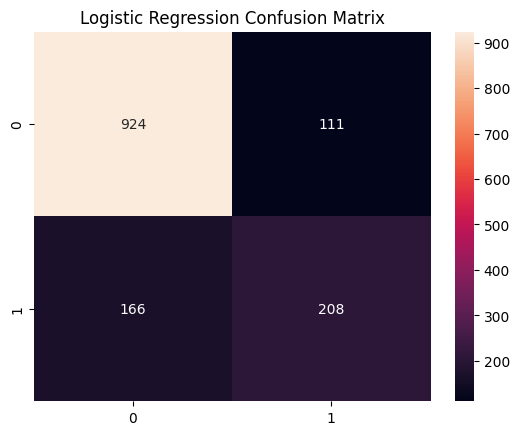

In [17]:
print(classification_report(y_test, y_pred_lr))

cm_lr = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm_lr, annot=True, fmt='d')
plt.title("Logistic Regression Confusion Matrix")
plt.show()

## Model 2: Decision Tree

In [18]:
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.794180269694819


In [19]:
feature_importance = pd.DataFrame({
'feature': X_train.columns,
'importance': dt_model.feature_importances_
}).sort_values('importance', ascending=False)

feature_importance.head(10)

,feature,importance
1,tenure,0.421435
10,InternetService_Fiber optic,0.357542
3,TotalCharges,0.047129
28,PaymentMethod_Electronic check,0.036761
9,MultipleLines_Yes,0.023630
12,OnlineSecurity_No internet service,0.020669
25,Contract_Two year,0.019599
22,StreamingMovies_No internet service,0.017379
2,MonthlyCharges,0.016847
19,TechSupport_Yes,0.012988


## Model 3: Random Forest

In [20]:
rf_model = RandomForestClassifier(
n_estimators=100,
random_state=42,
max_depth=10
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.8069552874378992


In [21]:
results = pd.DataFrame({
'Model': ['Logistic Regression','Decision Tree','Random Forest'],
'Accuracy': [lr_accuracy, dt_accuracy, rf_accuracy]
})

results = results.sort_values('Accuracy', ascending=False)

results

,Model,Accuracy
2,Random Forest,0.806955
0,Logistic Regression,0.803407
1,Decision Tree,0.794180


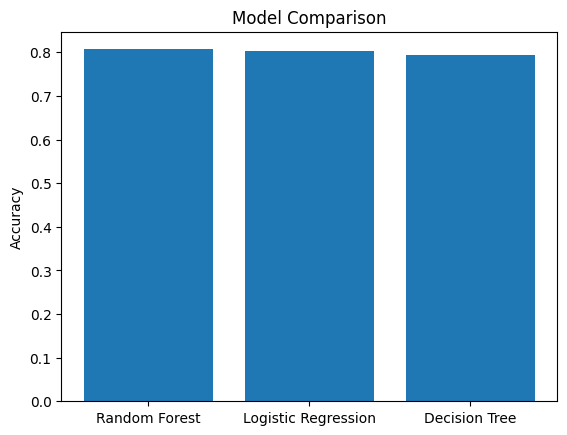

In [22]:
plt.bar(results['Model'], results['Accuracy'])

plt.title("Model Comparison")
plt.ylabel("Accuracy")

plt.show()

## Summary

Models trained:
1. Logistic Regression
2. Decision Tree
3. Random Forest

Best model: Random Forest (highest accuracy)

These models help predict which customers are likely to churn.